In [1]:
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import ImageNormalize, SqrtStretch

import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface
from sunpy.net import Fido
from sunpy.net import attrs as a

In [2]:
query = Fido.search(a.Time('2024-05-08 00:00:00', '2024-05-08 12:00:00'),
                    a.Instrument.aia,
                    a.Wavelength(193 * u.angstrom),
                    a.Sample(1 * u.h))
print(query)
files = Fido.fetch(query)

Results from 1 Provider:

12 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: http://docs.virtualsolar.org/wiki/VSOHealthReport
Total estimated size: 813.466 Mbyte

       Start Time               End Time        Source Instrument   Wavelength   Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size  
                                                                     Angstrom                                                                        Mibyte 
----------------------- ----------------------- ------ ---------- -------------- -------- --------- -------- ------------ ------------- ----------- --------
2024-05-08 00:00:04.000 2024-05-08 00:00:05.000    SDO        AIA 193.0 .. 193.0     JSOC intensity   NARROW         4096          4096    FULLDISK 64.64844
2024-05-08 01:00:06.000 2024-05-08 01:00:07.000    SDO        AIA 193.0 .. 193.0     JSOC intensity   NARROW         4096          4096    FULLDISK 64.64844

Files Downloaded:   0%|          | 0/12 [00:00<?, ?file/s]

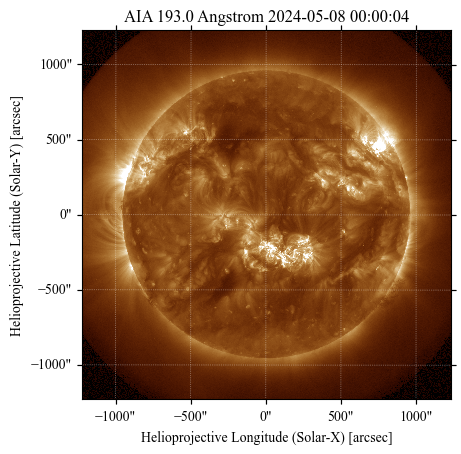

In [11]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'

aia_sequence = sunpy.map.Map(files, sequence=True)

fig = plt.figure()
ax = fig.add_subplot(projection=aia_sequence[0])
norm = ImageNormalize(vmin=0, vmax=3e3, stretch=SqrtStretch())
ani = aia_sequence.plot(axes=ax, norm=norm)

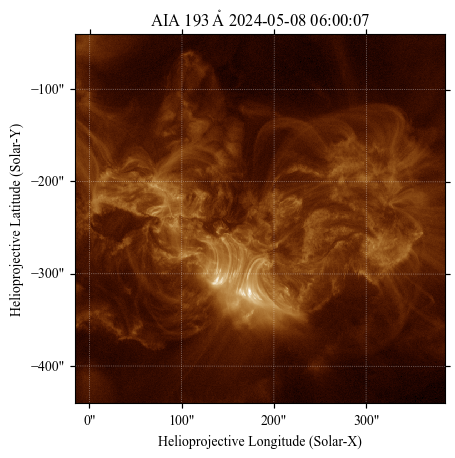

In [8]:
corner = SkyCoord(
    Tx=-15*u.arcsec, 
    Ty=-440*u.arcsec, 
    frame=aia_sequence[6].coordinate_frame
)
cutout_map = aia_sequence[6].submap(corner, width=400*u.arcsec, height=400*u.arcsec)

fig = plt.figure()
ax = fig.add_subplot(projection=cutout_map)
cutout_map.plot(axes=ax)

In [5]:
with propagate_with_solar_surface():
    aia_sequence_aligned = sunpy.map.Map(
        [m.reproject_to(cutout_map.wcs, preserve_date_obs=True) for m in aia_sequence],
        sequence=True
    )

2026-06-06 23:17:50 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.PillowWriter'>


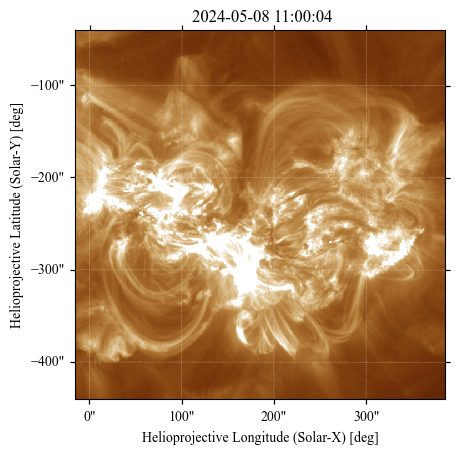

In [9]:
fig = plt.figure()
ax = fig.add_subplot(projection=aia_sequence_aligned[0])
ani = aia_sequence_aligned.plot(axes=ax, cmap='sdoaia193', norm=norm)

ani.save('solar_active_region.gif', writer='pillow', fps=3)

plt.show()